### This notebook is designed to understand and implement the important concepts from California Housing as under Geron's Ch2

Various steps of a ML End to End project
1) Big Picture understanding of the problem
2) Get the Data
3) Explore and Visualise the data
4) Preprocess the Data
5) Select a Model
6) Fine-Tune the model parameters
7) Present the solution
8) Launch, Monitor.. etc

## Get the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import tarfile
import pandas as pd
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

C:\Users\Taif Al Ghazali\AppData\Local\Temp\ipykernel_9836\1618124921.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


## Time to Explore this data

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


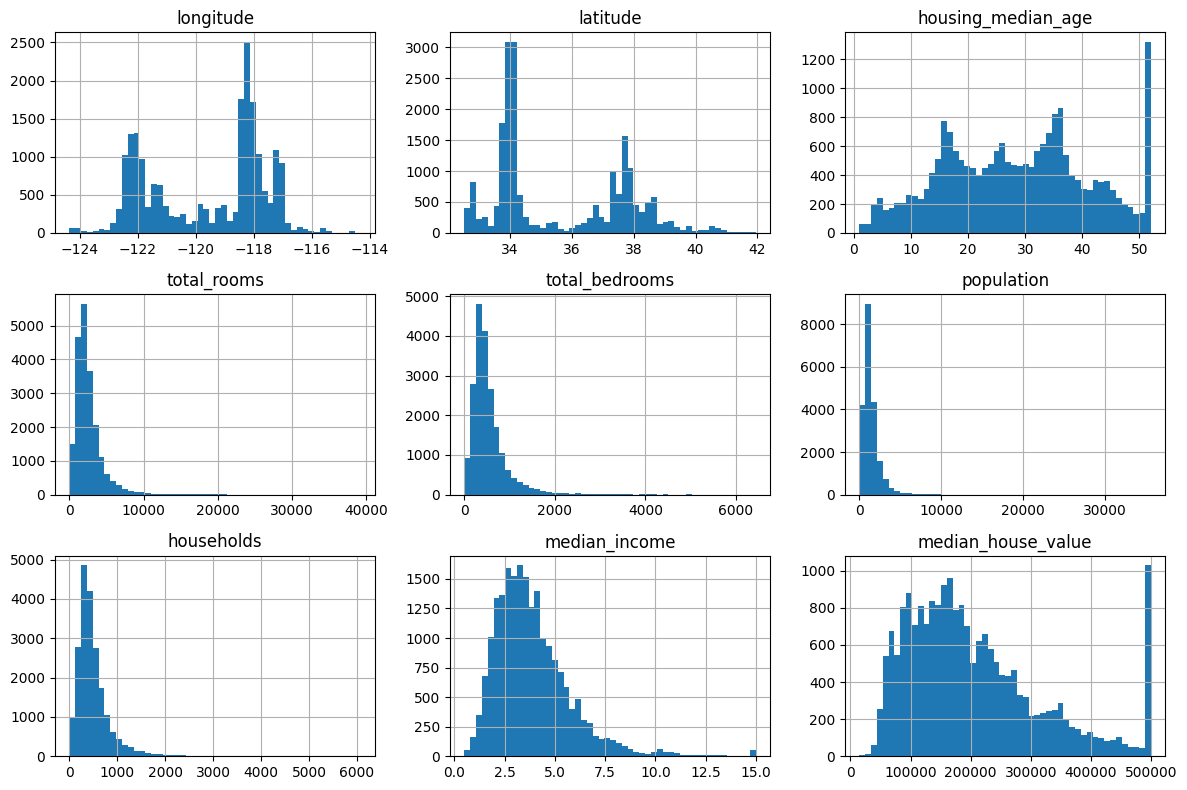

In [6]:
housing.hist(bins=50, figsize= (12,8))
plt.tight_layout()
plt.show()

***We can notice that there are quite a few features over here which are 'skewed' right... we will have to take care of them before the final solution.***

In [13]:
housing[housing["population"] > 20000]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9795,-121.79,36.64,11.0,32627.0,6445.0,28566.0,6082.0,2.3087,118800.0,<1H OCEAN
12594,-117.42,33.35,14.0,25135.0,4819.0,35682.0,4769.0,2.5729,134400.0,<1H OCEAN


*So clearly, we can see that the population and it's correlated features (total bedrooms.. etc) is massively skewed right. extremities are pretty high*

*We've been told that the **housing median age** and **median house value** features have been capped at max*

### Seperating the train and test sets

*Essential to do this before we do any further data exploration/ preprocessing*

*Any changes we make to the train set, be it addition/ removal of features or taking care of **NaN** values, we must reciprocate that in the test set as well*

*It is rumored that **median income** has a high importance in deciding what the median house value will be. We should make sure our test and train set are representative of the original distribution*

*Hence, we have to **stratify** our train, test split*

In [18]:
housing["median_income"].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [19]:
housing[housing["median_income"] > 6.0].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,2362.000000,2362.000000,2362.000000,2362.000000,2337.000000,2362.000000,2362.000000,2362.000000,2362.000000
mean,-119.607570,35.336232,25.574090,3398.914479,502.565682,1389.890347,480.190517,7.722912,378671.235394
std,2.005111,1.894027,12.959644,2953.054535,446.832445,1274.766529,412.177573,1.931465,101810.220917
min,-122.720000,32.610000,2.000000,8.000000,1.000000,13.000000,1.000000,6.005000,67500.000000
25%,-121.990000,33.850000,16.000000,1817.500000,267.000000,727.000000,260.250000,6.379100,293500.000000
50%,-118.500000,34.170000,25.000000,2671.000000,394.000000,1076.500000,381.000000,7.032750,371800.000000
75%,-117.920000,37.430000,34.750000,3983.500000,583.000000,1637.750000,569.750000,8.242750,500001.000000
max,-115.390000,40.120000,52.000000,37937.000000,5471.000000,16122.000000,5189.000000,15.000100,500001.000000


In [20]:
housing['income_cat'] = pd.cut(housing['median_income'], bins= [0, 1.5, 3.0, 4.5, 6.0, np.inf], labels = [1,2,3,4,5])

<Axes: xlabel='income_cat'>

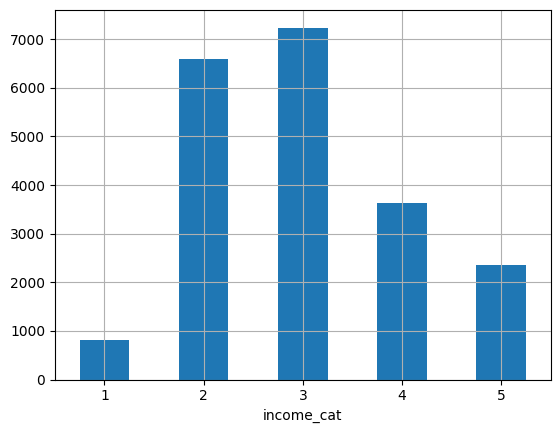

In [23]:
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid= True)

In [24]:
from sklearn.model_selection import train_test_split
train_set, test_set  = train_test_split(housing, test_size=0.2)

In [25]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1252 to 129
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB


In [26]:
strat_train_set, strat_test_set  = train_test_split(housing, stratify=housing['income_cat'], test_size=0.2)

In [29]:
housing['income_cat'].value_counts()/ len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [30]:
train_set['income_cat'].value_counts()/ len(train_set)

income_cat
3    0.352350
2    0.320070
4    0.174661
5    0.113614
1    0.039305
Name: count, dtype: float64

In [31]:
strat_train_set['income_cat'].value_counts()/ len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

*Clearly, the difference is'nt much but if it is a highly important feature, it matters*

In [32]:
for set_ in (train_set, test_set):
    set_.drop('income_cat', axis =1 , inplace= True)

In [33]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis =1 , inplace= True)

We would not need the income_cat feature any more

### Exploring Geographical Aspects of the data

In [34]:
housing = strat_train_set.copy() ## have a copy of training set

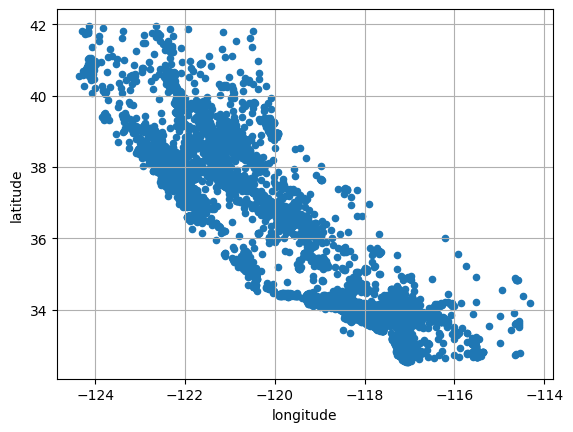

In [35]:
housing.plot(kind="scatter", x= 'longitude', y= 'latitude', grid= True)
plt.show()

*To make the population density more visible, we introduce **alpha***

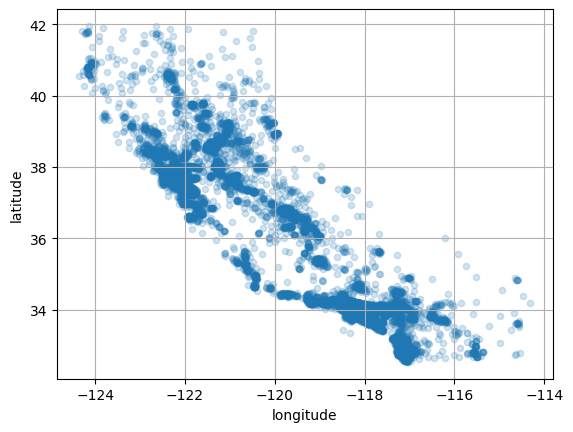

In [36]:
housing.plot(kind="scatter", x= 'longitude', y= 'latitude', alpha=0.2, grid= True) 
plt.show()

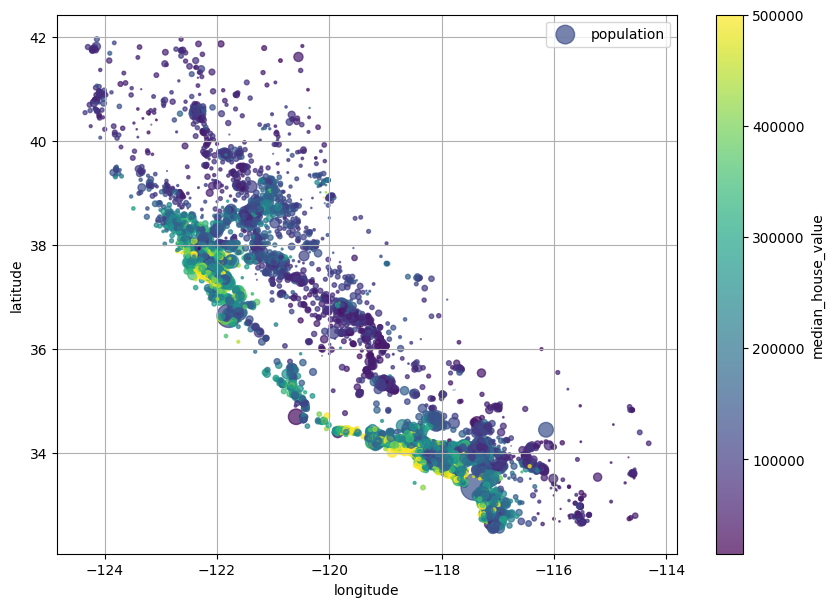

In [38]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            s= housing['population']/100, label = "population", alpha= 0.7, 
            c= "median_house_value", cmap = 'viridis', colorbar= True, 
            legend = True, sharex= False, figsize = (10,7))

plt.show()

### Exploring Correlations

In [39]:
corr_matrix= housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending= False)

median_house_value    1.000000
median_income         0.687923
total_rooms           0.123999
housing_median_age    0.105582
households            0.057082
total_bedrooms        0.040400
population           -0.032669
longitude            -0.050814
latitude             -0.138728
Name: median_house_value, dtype: float64

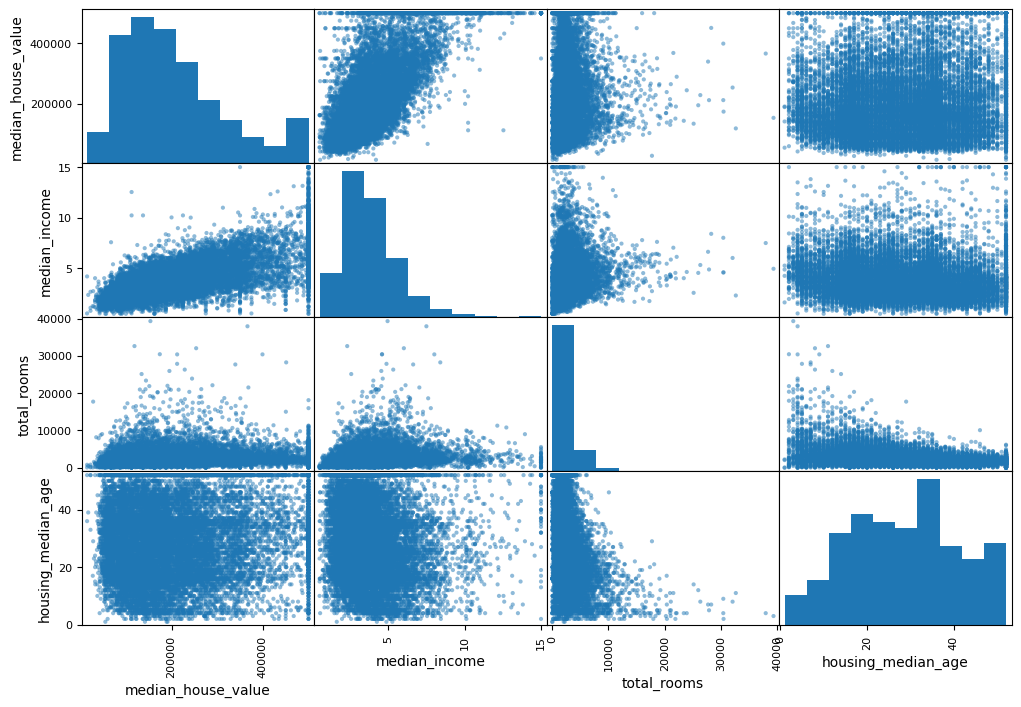

In [40]:
from pandas.plotting import scatter_matrix

attributes= ['median_house_value', "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize= (12, 8))
plt.show()

*It's the median house value and median income which seem highly correlated*

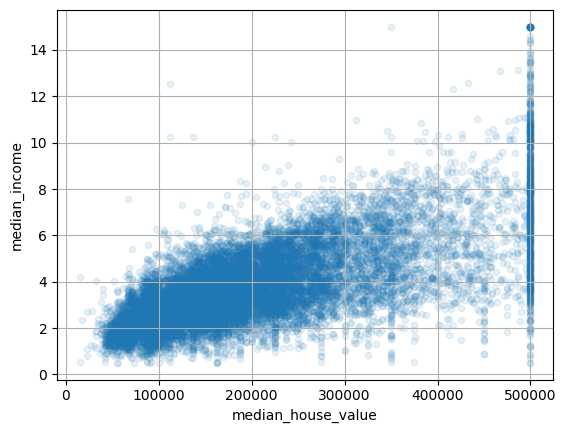

In [41]:
housing.plot(kind="scatter", x="median_house_value", y="median_income", alpha= 0.1, grid= True)
plt.show()

*The cap at **500k** now is highly apparent*

*Let's try and add some more attributes*

In [42]:
housing['rooms_per_house'] = housing['total_rooms']/ housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms']/ housing['total_rooms']
housing['people_per_house'] = housing['population']/ housing['households']

In [43]:
corr_matrix= housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687923
rooms_per_house       0.154934
total_rooms           0.123999
housing_median_age    0.105582
households            0.057082
total_bedrooms        0.040400
people_per_house     -0.020246
population           -0.032669
longitude            -0.050814
latitude             -0.138728
bedrooms_ratio       -0.255915
Name: median_house_value, dtype: float64

There we go, both our **rooms_per_house** and **bedrooms_ratio** seem pretty imp features now

## Time for data pre processing

In [46]:
housing= strat_train_set.drop('median_house_value', axis= 1) ## We revert back to org train set
housing_labels = strat_train_set['median_house_value'].copy()

In [47]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 19697 to 6602
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16349 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [48]:
"""
Three ways to deal with NaN values...
1) Drop the corresponding districts -> housing.dropna(subset = ['total_bedrooms'], inplace= True)
2) Drop the entire feature -> housing.drop('total_bedrooms', axis=1)
3) Imputation -> median= housing['total_bedrooms'].median() .. housing['total_bedrooms'].fillna(median, inplace= True)
"""


"\nThree ways to deal with NaN values...\n1) Drop the corresponding districts -> housing.dropna(subset = ['total_bedrooms'], inplace= True)\n2) Drop the entire feature -> housing.drop('total_bedrooms', axis=1)\n3) Imputation -> median= housing['total_bedrooms'].median() .. housing['total_bedrooms'].fillna(median, inplace= True)\n"

In [52]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

In [53]:
housing_num = housing.select_dtypes(include= [np.number])
imputer.fit(housing_num)

SimpleImputer()

In [54]:
imputer.strategy

'mean'

In [55]:
imputer.statistics_

array([-119.55871003,   35.62080063,   28.64147287, 2635.77034884,
        538.05657838, 1428.66890746,  500.11076793,    3.86875484])

In [56]:
housing_num.median().values

array([-118.48  ,   34.25  ,   29.    , 2123.    ,  435.    , 1167.    ,
        409.    ,    3.5332])

In [58]:
X = imputer.transform(housing_num)

In [59]:
X

array([[-1.1743e+02,  3.3930e+01,  1.5000e+01, ...,  3.0120e+03,
         1.2400e+03,  2.1865e+00],
       [-1.1849e+02,  3.4250e+01,  3.3000e+01, ...,  9.6000e+02,
         3.6200e+02,  4.3333e+00],
       [-1.1728e+02,  3.3180e+01,  1.6000e+01, ...,  8.4200e+02,
         5.3800e+02,  2.1205e+00],
       ...,
       [-1.1556e+02,  3.2800e+01,  2.8000e+01, ...,  1.3350e+03,
         3.9700e+02,  1.5987e+00],
       [-1.2232e+02,  3.7930e+01,  3.3000e+01, ...,  2.1600e+02,
         6.3000e+01,  2.6750e+00],
       [-1.2112e+02,  3.7480e+01,  5.0000e+00, ...,  3.0620e+03,
         7.1300e+02,  3.2396e+00]])

In [60]:
housing_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index)
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 19697 to 6602
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


### Text and Categorical Attributes

In [64]:
housing_cat= housing[['ocean_proximity']]

In [66]:
housing_cat

,ocean_proximity
19697,INLAND
2484,<1H OCEAN
3429,NEAR OCEAN
17227,<1H OCEAN
17037,<1H OCEAN
...,...
11765,INLAND
1703,<1H OCEAN
11837,INLAND
8308,NEAR BAY


In [67]:
housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7343
INLAND             5237
NEAR OCEAN         2078
NEAR BAY           1852
ISLAND                2
Name: count, dtype: int64

In [68]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder= OneHotEncoder()
housing_cat_1hot= cat_encoder.fit_transform(housing_cat)

In [69]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

***Sparse Matrix** is used when we have loads of 0s to fill, it helps managing memory efficiently. It only remembers the non 0s and their location in the matrix*

In [71]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [72]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [74]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

## Feature Scaling and Transformation

***Min Max Scaling*** -> subtracts min from each value and then divides by range (max- min).. normalisaton

In [75]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaled = MinMaxScaler(feature_range = (-1,1))
housing_num_min_max_scaled = min_max_scaled.fit_transform(housing_num)

**Standard Scaler** -> subtract mean from each val and then divide by standard deviation.. less affected by outliers

In [76]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled= std_scaler.fit_transform(housing_num)

Handing heavy tail fns

1) sqr root
2) raise to a power bw (0,1)
3) log
4) bucketizing
5) multimodal fns -> bucketize or similarity measure (rbf kernel)

<Axes: >

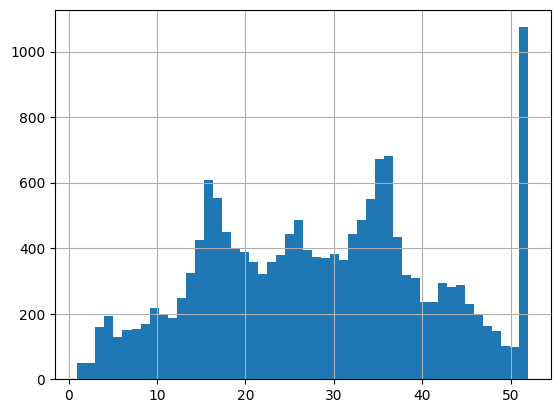

In [77]:
housing['housing_median_age'].hist(bins=50)

In [78]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma= 0.1)

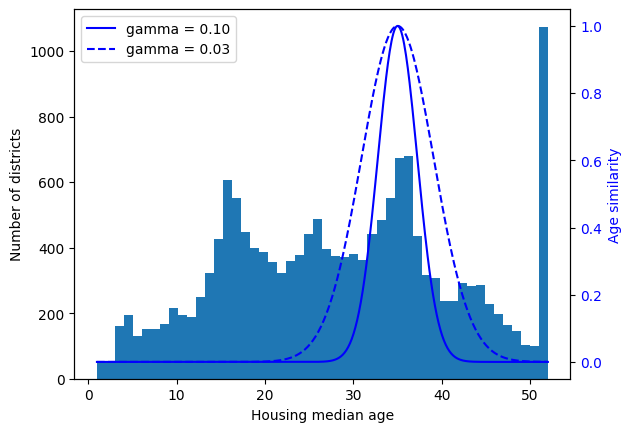

In [79]:
ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

In [80]:
## Check correlation with the above feature at the end

In [81]:
from sklearn.linear_model import LinearRegression

target_scaler= StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']], scaled_labels)
some_new_data = housing[['median_income']].iloc[:5]

scaled_predictions= model.predict(some_new_data)
predictions= target_scaler.inverse_transform(scaled_predictions)

In [82]:
predictions

array([[136510.7175846 ],
       [226451.11027818],
       [133745.64123013],
       [275585.67919519],
       [497516.57271844]])

In [53]:
## use TransformedTargetRegressor

In [83]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                  transformer= StandardScaler())

In [84]:
model.fit(housing[['median_income']], housing_labels)

TransformedTargetRegressor(regressor=LinearRegression(),
                           transformer=StandardScaler())

In [85]:
predictions= model.predict(some_new_data)
predictions

array([136510.7175846 , 226451.11027818, 133745.64123013, 275585.67919519,
       497516.57271844])

the above ->
1) scales the labels first
2) trains model on scaled values
3) upon making a prediciton, makes it on the scaled range
4) unscales it using the inverse_transform method
5) then returns the value

### Custom Transformers

In [58]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func= np.exp)
log_pop = log_transformer.transform(housing[['population']])

In [59]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args= dict(Y=[[35]], gamma= 0.1))
age_simil_35 = rbf_transformer.transform(housing[['housing_median_age']])

In [60]:
age_simil_35

array([[8.20849986e-02],
       [1.66155727e-03],
       [5.55951324e-06],
       ...,
       [8.20849986e-02],
       [2.81118530e-13],
       [2.81118530e-13]])

In [61]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, 
                                    kw_args = dict(Y= [sf_coords], gamma= 0.1))
sf_simil= sf_transformer.transform(housing[['latitude', 'longitude']])

In [62]:
sf_simil

array([[0.90824456],
       [0.01846825],
       [0.00269883],
       ...,
       [0.03341402],
       [0.999937  ],
       [0.03180509]])

<Axes: xlabel='longitude', ylabel='latitude'>

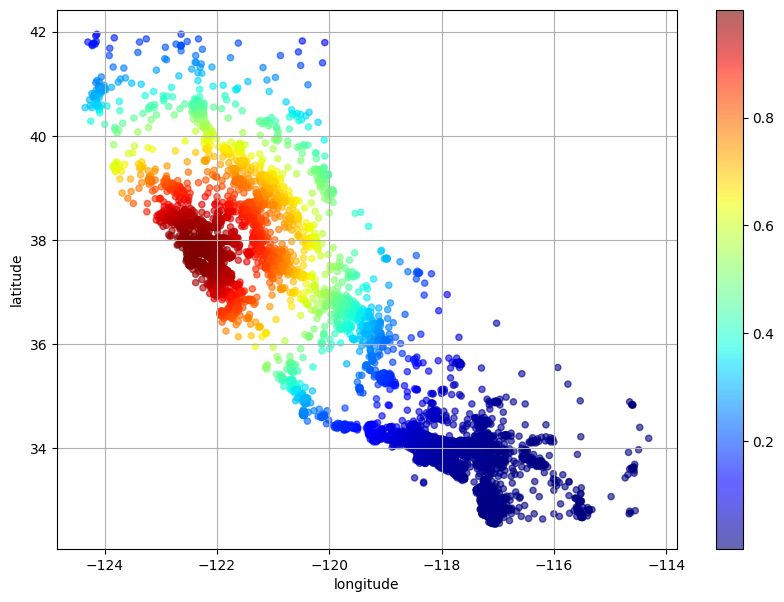

In [63]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            c= sf_simil.ravel(), cmap = 'jet', colorbar= True, 
            alpha=0.6, sharex= False, legend= True, figsize = (10,7))


In [64]:
ration_transformer = FunctionTransformer(lambda X: X[:,[0]]/ X[:,[1]])
ration_transformer.transform(np.array([[1,2],[3,4]]))

array([[0.5 ],
       [0.75]])

In [65]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__ (self, with_mean = True):
        self.with_mean = with_mean

    def fit(self, X, y= None): 
        X= check_array(X)
        self.mean_ = X.mean(axis= 0)
        self.scale_ = X.std(axis= 0)
        self.n_features_in_ = X.shape[1] 
        return self

    def transform(self, X):
        check_is_fitted(self)
        X= check_array(X) 
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X- self.mean_ 
        return X/self.scale_

In [66]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__ (self, n_clusters = 10, gamma=1.0, random_state= None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state= random_state

    def fit(self, X, y=None, sample_weight= None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight= sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [67]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
similarities= cluster_simil.fit_transform(housing[['latitude', 'longitude']], 
                                         sample_weight = housing_labels)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Taif Al Ghazali\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Taif Al Ghazali\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Taif Al Ghazali\anaconda3\Lib\subprocess.py", line 1538, in _exec

In [68]:
similarities.max(axis=1).shape

(16512,)

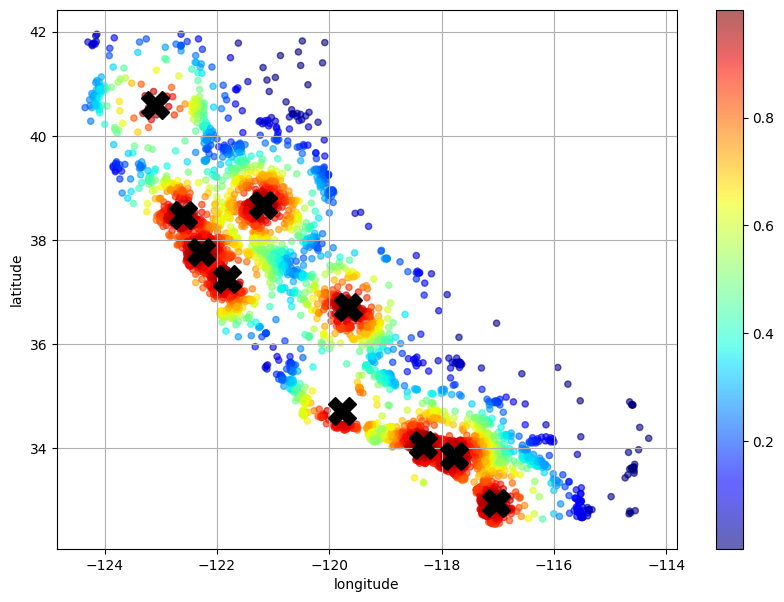

In [69]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            c= similarities.max(axis=1), cmap = 'jet', colorbar= True, 
            alpha=0.6, sharex= False, legend= True, figsize = (10,7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

In [70]:
similarities.shape

(16512, 10)

In [71]:
housing.shape

(16512, 9)

Pipeline constructor takes a list of name/estimator pairs defining a sequence of steps... estimators must be all transformers.. have a fit.transform()
method except for the last one which can be anything ... transformer/ predictor...

In [72]:
from sklearn.pipeline import Pipeline

num_pipeline= Pipeline([
    ('impute', SimpleImputer(strategy= 'median')),
    ('standardize', StandardScaler()),
])

In [73]:
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('standardize', StandardScaler())])

In [74]:
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
6339,-121.43,37.73,40.0,1718.0,391.0,1312.0,388.0,2.9955
6929,-117.16,34.26,27.0,9285.0,1621.0,1135.0,410.0,2.5446
19897,-116.01,33.51,24.0,2985.0,958.0,4042.0,905.0,1.7344
8571,-122.07,37.35,35.0,1579.0,210.0,570.0,196.0,8.5888
20075,-122.42,37.80,52.0,1777.0,486.0,932.0,427.0,3.3643
...,...,...,...,...,...,...,...,...
5215,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516
1824,-121.15,39.23,13.0,3883.0,763.0,1816.0,682.0,2.8102
12473,-117.86,34.13,40.0,1304.0,280.0,607.0,256.0,2.5880
10878,-122.41,37.80,52.0,2583.0,672.0,1335.0,613.0,3.1477


In [75]:
housing_num_prepared= num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-0.92,  0.98,  0.91, -0.42, -0.35, -0.1 , -0.29, -0.46],
       [ 1.2 , -0.65, -0.12,  3.03,  2.56, -0.25, -0.23, -0.7 ]])

In [76]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns= num_pipeline.get_feature_names_out(),
    index= housing_num.index
)

In [77]:
df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
6339,-0.922668,0.979728,0.909205,-0.420904,-0.347141,-0.099521,-0.291599,-0.461555
6929,1.203712,-0.645816,-0.124471,3.034898,2.561859,-0.254569,-0.234370,-0.699456
19897,1.776391,-0.997159,-0.363012,0.157727,0.993837,2.291897,1.053282,-1.126928
8571,-1.241376,0.801714,0.511637,-0.484385,-0.775213,-0.749496,-0.791052,2.489545
20075,-1.415669,1.012520,1.863367,-0.393959,-0.122462,-0.432392,-0.190148,-0.266971
...,...,...,...,...,...,...,...,...
5215,-0.927648,1.307647,-2.032795,16.751699,13.415029,13.034004,12.636949,0.570510
1824,-0.783233,1.682412,-1.237660,0.567838,0.532654,0.341972,0.473188,-0.559322
12473,0.855126,-0.706716,0.909205,-0.609976,-0.609660,-0.717084,-0.634973,-0.676558
10878,-1.410690,1.012520,1.863367,-0.025864,0.317435,-0.079373,0.293697,-0.381252


In [78]:
num_pipeline.steps

[('impute', SimpleImputer(strategy='median')),
 ('standardize', StandardScaler())]

In [79]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

In [80]:
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
               'total_bedrooms', 'population', 'households', 'median_income']
cat_attribs = ['ocean_proximity']


cat_pipeline= make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'))

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

In [81]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing= make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

In [82]:
housing_prepared= preprocessing.fit_transform(housing)

In [83]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
6339,-121.43,37.73,40.0,1718.0,391.0,1312.0,388.0,2.9955,INLAND
6929,-117.16,34.26,27.0,9285.0,1621.0,1135.0,410.0,2.5446,INLAND
19897,-116.01,33.51,24.0,2985.0,958.0,4042.0,905.0,1.7344,INLAND
8571,-122.07,37.35,35.0,1579.0,210.0,570.0,196.0,8.5888,<1H OCEAN
20075,-122.42,37.80,52.0,1777.0,486.0,932.0,427.0,3.3643,NEAR BAY
...,...,...,...,...,...,...,...,...,...
5215,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,INLAND
1824,-121.15,39.23,13.0,3883.0,763.0,1816.0,682.0,2.8102,INLAND
12473,-117.86,34.13,40.0,1304.0,280.0,607.0,256.0,2.5880,INLAND
10878,-122.41,37.80,52.0,2583.0,672.0,1335.0,613.0,3.1477,NEAR BAY


In [84]:
housing_prepared = pd.DataFrame(housing_prepared, columns= preprocessing.get_feature_names_out(), index= housing.index)

In [85]:
housing_prepared

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
6339,-0.922668,0.979728,0.909205,-0.420904,-0.347141,-0.099521,-0.291599,-0.461555,0.0,1.0,0.0,0.0,0.0
6929,1.203712,-0.645816,-0.124471,3.034898,2.561859,-0.254569,-0.234370,-0.699456,0.0,1.0,0.0,0.0,0.0
19897,1.776391,-0.997159,-0.363012,0.157727,0.993837,2.291897,1.053282,-1.126928,0.0,1.0,0.0,0.0,0.0
8571,-1.241376,0.801714,0.511637,-0.484385,-0.775213,-0.749496,-0.791052,2.489545,1.0,0.0,0.0,0.0,0.0
20075,-1.415669,1.012520,1.863367,-0.393959,-0.122462,-0.432392,-0.190148,-0.266971,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5215,-0.927648,1.307647,-2.032795,16.751699,13.415029,13.034004,12.636949,0.570510,0.0,1.0,0.0,0.0,0.0
1824,-0.783233,1.682412,-1.237660,0.567838,0.532654,0.341972,0.473188,-0.559322,0.0,1.0,0.0,0.0,0.0
12473,0.855126,-0.706716,0.909205,-0.609976,-0.609660,-0.717084,-0.634973,-0.676558,0.0,1.0,0.0,0.0,0.0
10878,-1.410690,1.012520,1.863367,-0.025864,0.317435,-0.079373,0.293697,-0.381252,0.0,0.0,0.0,1.0,0.0


In [86]:
## Creating the one and final pipeline

In [87]:
def column_ratio(X):
    return X[:, [0]]/ X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out='one-to-one'),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
default_num_pipeline= make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler())


preprocessing= ColumnTransformer([
        ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
        ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
        ('people_per_house', ratio_pipeline(), ['population', 'households']),
        ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
        ('geo', cluster_simil, ['latitude', 'longitude']),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder= default_num_pipeline)

In [88]:
housing_prepared= preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [89]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [137]:
from sklearn.linear_model import LinearRegression

lin_reg= make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])),
                ('linearregression', LinearRegression())])

In [138]:
housing_predictions= lin_reg.predict(housing)
housing_predictions[:5].round(-2)

array([124000., 143500.,   5500., 379600., 265100.])

In [92]:
housing_labels.iloc[:5].values

array([134700., 135200.,  66400., 500001., 420000.])

In [139]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)

In [140]:
lin_rmse

69022.87733379361

In [141]:
lin_rmse

69022.87733379361

In [95]:
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 6339 to 14461
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16342 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [96]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 6339 to 14461
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16342 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [142]:
from sklearn.tree import DecisionTreeRegressor

tree_reg= make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

housing_predictions= tree_reg.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_predictions)

tree_rmse

0.0

In [143]:
from sklearn.model_selection import cross_val_score

tree_rmses= -cross_val_score(tree_reg, housing, housing_labels, 
                            scoring= "neg_root_mean_squared_error", cv=10)

In [144]:
tree_rmses

array([68073.92288737, 66834.97618804, 68032.39940495, 64801.16231566,
       65956.35138565, 64227.03112862, 67256.5828718 , 66739.11964337,
       68100.73541593, 67744.49785858])

In [100]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66776.677910
std       1384.874603
min      64227.031129
25%      66152.043450
50%      67045.779530
75%      67960.424018
max      68100.735416
dtype: float64

In [101]:
from sklearn.ensemble import RandomForestRegressor

forest_reg= make_pipeline(preprocessing, 
                        RandomForestRegressor(random_state=42))

forest_rmses= -cross_val_score(forest_reg, housing, housing_labels, 
                              scoring= 'neg_root_mean_squared_error', cv=10)

In [145]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47010.245923
std       2127.786412
min      44968.370982
25%      45359.925002
50%      45989.574302
75%      48823.137258
max      50819.884516
dtype: float64

In [103]:
from sklearn.model_selection import GridSearchCV

full_pipeline= Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]}, 
    {'preprocessing__geo__n_clusters': [10,15],
    'random_forest__max_features': [6, 8, 10]},
]

grid_search= GridSearchCV(full_pipeline, param_grid, cv= 3, 
                         scoring= 'neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [146]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [105]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020...
                                                                    n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B179490>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

In [106]:
grid_search.cv_results_

{'mean_fit_time': array([3.82044355, 5.55281591, 6.91325363, 3.94611541, 5.375856  ,
        6.95319359, 3.85902373, 5.53450123, 7.0590059 , 5.46965265,
        7.00506934, 8.5042092 , 5.43480126, 7.1384937 , 8.62486935]),
 'std_fit_time': array([0.01906298, 0.12017103, 0.10512178, 0.07363108, 0.05081418,
        0.09055866, 0.03672227, 0.09127925, 0.08669801, 0.06516816,
        0.11290326, 0.10447726, 0.02521253, 0.11109345, 0.01652982]),
 'mean_score_time': array([0.14560159, 0.17771912, 0.15039937, 0.14591861, 0.14863674,
        0.14599331, 0.15165718, 0.15168357, 0.14799976, 0.14536858,
        0.14704672, 0.1443615 , 0.15164908, 0.14396175, 0.14708018]),
 'std_score_time': array([0.00159404, 0.02316527, 0.00709918, 0.00161219, 0.00501558,
        0.00129551, 0.00669392, 0.00655168, 0.00308419, 0.00067335,
        0.00279574, 0.00100503, 0.00974921, 0.00208693, 0.00397425]),
 'param_preprocessing__geo__n_clusters': masked_array(data=[5, 5, 5, 8, 8, 8, 10, 10, 10, 10, 10, 10, 15, 

In [107]:
cv_res= pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,5.434801,0.025213,0.151649,0.009749,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43283.267014,-42847.589704,-46530.982007,-44220.612908,1643.331516,1
13,7.138494,0.111093,0.143962,0.002087,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-43531.509477,-43044.478517,-46929.909991,-44501.965995,1728.290837,2
14,8.624869,0.016530,0.147080,0.003974,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-43983.732016,-43611.944856,-47340.933733,-44978.870202,1677.113496,3
7,5.534501,0.091279,0.151684,0.006552,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44146.501899,-43483.687357,-47908.865382,-45179.684879,1948.700497,4
9,5.469653,0.065168,0.145369,0.000673,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44146.501899,-43483.687357,-47908.865382,-45179.684879,1948.700497,4


In [108]:
full_pipeline


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020...
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])),
                ('random_forest', RandomForestRegressor(random_state=42))])

In [109]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs= {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                'random_forest__max_features': randint(low=2, high= 20)}

rnd_search= RandomizedSearchCV(
    full_pipeline, param_distributions= param_distribs, n_iter=10, cv=3, 
    scoring= 'neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020D4B14B200>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020D4B14BC20>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [110]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [111]:
rnd_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020...
                                                                    n_clusters=45,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B5E5580>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=9, random_state=42))])

In [112]:
rv_res= pd.DataFrame(rnd_search.cv_results_)
rv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
rv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,8.236726,0.083599,0.164954,0.003987,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41533.356039,-40792.561941,-44467.524499,-42264.480826,1586.872194,1
8,6.446970,0.015675,0.148995,0.001731,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41836.363840,-41266.359365,-45046.324967,-42716.349390,1663.894211,2
5,4.074718,0.017505,0.156979,0.008241,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-42147.191604,-41423.344931,-44844.085445,-42804.873993,1471.909420,3
0,13.699254,0.084612,0.146842,0.002526,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42134.899523,-41707.972652,-45535.009205,-43125.960460,1712.348004,4
2,7.161860,0.059915,0.145858,0.001927,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42431.288307,-42045.065490,-45778.200073,-43418.184623,1676.215322,5


In [113]:
final_model = rnd_search.best_estimator_
feature_importances= final_model['random_forest'].feature_importances_

In [147]:
feature_importances.round(3)

array([0.071, 0.052, 0.047, 0.007, 0.008, 0.008, 0.007, 0.182, 0.006,
       0.01 , 0.029, 0.008, 0.01 , 0.007, 0.013, 0.011, 0.005, 0.004,
       0.008, 0.01 , 0.011, 0.012, 0.008, 0.011, 0.009, 0.007, 0.009,
       0.006, 0.014, 0.018, 0.009, 0.012, 0.023, 0.023, 0.019, 0.02 ,
       0.019, 0.004, 0.005, 0.012, 0.013, 0.006, 0.037, 0.013, 0.012,
       0.006, 0.01 , 0.01 , 0.01 , 0.009, 0.011, 0.01 , 0.003, 0.002,
       0.081, 0.   , 0.   , 0.003, 0.012])

In [115]:
sorted(zip(feature_importances, final_model['preprocessing'].get_feature_names_out()), reverse= True)

[(0.18202290786625394, 'log__median_income'),
 (0.08095822444725849, 'cat__ocean_proximity_INLAND'),
 (0.07136552721377826, 'bedrooms__ratio'),
 (0.05229308438399123, 'rooms_per_house__ratio'),
 (0.046758542192471955, 'people_per_house__ratio'),
 (0.0367431344157151, 'geo__Cluster 34 similarity'),
 (0.029157041021020364, 'geo__Cluster 2 similarity'),
 (0.023434166274757962, 'geo__Cluster 24 similarity'),
 (0.02273590626101249, 'geo__Cluster 25 similarity'),
 (0.01996525155674759, 'geo__Cluster 27 similarity'),
 (0.019366924865441556, 'geo__Cluster 26 similarity'),
 (0.018623287023909897, 'geo__Cluster 28 similarity'),
 (0.018002623298209338, 'geo__Cluster 21 similarity'),
 (0.013952093557317094, 'geo__Cluster 20 similarity'),
 (0.012925466265447492, 'geo__Cluster 32 similarity'),
 (0.012721175396503703, 'geo__Cluster 6 similarity'),
 (0.012597866470694228, 'geo__Cluster 35 similarity'),
 (0.012147877048571381, 'geo__Cluster 31 similarity'),
 (0.011686751610809707, 'geo__Cluster 36 simi

In [148]:
X_test= strat_test_set.drop("median_house_value", axis=1)
y_test= strat_test_set['median_house_value'].copy()

final_predictions= final_model.predict(X_test)

final_rmse= root_mean_squared_error(y_test, final_predictions)
final_rmse

41393.90304364593

In [117]:
import joblib

joblib.dump(final_model, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']

In [150]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 6339 to 14461
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16342 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [151]:
preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('bedrooms',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020D4B5EBBA0>,
                                                                      func=<function column_r...
                                 ['total_bedrooms', 'total_rooms', 'population',
                                  'households', 'median_income']),
                                ('geo',
                                 ClusterSimilarity(gamma=1, random_state=42),
                                 ['latitude', 'longitude']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])

In [155]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
6339,-121.43,37.73,40.0,1718.0,391.0,1312.0,388.0,2.9955,INLAND
6929,-117.16,34.26,27.0,9285.0,1621.0,1135.0,410.0,2.5446,INLAND
19897,-116.01,33.51,24.0,2985.0,958.0,4042.0,905.0,1.7344,INLAND
8571,-122.07,37.35,35.0,1579.0,210.0,570.0,196.0,8.5888,<1H OCEAN
20075,-122.42,37.80,52.0,1777.0,486.0,932.0,427.0,3.3643,NEAR BAY
...,...,...,...,...,...,...,...,...,...
5215,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,INLAND
1824,-121.15,39.23,13.0,3883.0,763.0,1816.0,682.0,2.8102,INLAND
12473,-117.86,34.13,40.0,1304.0,280.0,607.0,256.0,2.5880,INLAND
10878,-122.41,37.80,52.0,2583.0,672.0,1335.0,613.0,3.1477,NEAR BAY


In [158]:
from sklearn.svm import SVR

full_pipeline= Pipeline([
    ('preprocessing', preprocessing),
    ('support_vector', SVR())
])

param_grid = [
    {'support_vector__kernel': ['linear', 'rbf'],
    'support_vector__C': [1.0, 2.0, 5.0]}, 
]

grid_search= GridSearchCV(full_pipeline, param_grid, cv= 3, 
                         scoring= 'neg_root_mean_squared_error')
grid_search.fit(housing[:5000], housing_labels[:5000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])),
                                       ('support_vector', SVR())]),
             param_grid=[{'support_vector__C': [1.0, 2.0, 5.0],
                          'support_vector__kernel': ['linear', 'rbf']}],
             scoring='neg_root_mean_squared_error')

In [159]:
grid_search.best_params_

{'support_vector__C': 5.0, 'support_vector__kernel': 'linear'}

In [160]:
cv_res= pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_support_vector__C,param_support_vector__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
4,0.440523,0.008007,0.123689,0.002641,5.0,linear,"{'support_vector__C': 5.0, 'support_vector__ke...",-106215.364439,-108909.788160,-114671.367051,-109932.173217,3527.033546,1
2,0.433204,0.008645,0.123843,0.001915,2.0,linear,"{'support_vector__C': 2.0, 'support_vector__ke...",-110496.404663,-113135.472013,-119043.969628,-114225.282102,3573.605204,2
0,0.455968,0.011269,0.132781,0.011061,1.0,linear,"{'support_vector__C': 1.0, 'support_vector__ke...",-112101.029082,-114729.255977,-120588.335165,-115806.206742,3547.624402,3
5,0.703344,0.051454,0.544661,0.078280,5.0,rbf,"{'support_vector__C': 5.0, 'support_vector__ke...",-113481.347993,-116042.146829,-121867.005502,-117130.166775,3508.813049,4
3,0.638198,0.007017,0.423272,0.002876,2.0,rbf,"{'support_vector__C': 2.0, 'support_vector__ke...",-113703.576213,-116306.229766,-122146.188105,-117385.331361,3530.133999,5


In [165]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

svr_pipeline= Pipeline([
    ('preprocessing', preprocessing),
    ('svr', SVR())
])

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `loguniform()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
    }

rnd_search = RandomizedSearchCV(svr_pipeline,
                                param_distributions=param_distribs,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                verbose = 2,
                                random_state=42)
rnd_search.fit(housing[:5000], housing_labels[:5000])

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END svr__C=629.7823295913721, svr__gamma=3.010121430917521, svr__kernel=linear; total time=   0.5s
[CV] END svr__C=629.7823295913721, svr__gamma=3.010121430917521, svr__kernel=linear; total time=   0.5s
[CV] END svr__C=629.7823295913721, svr__gamma=3.010121430917521, svr__kernel=linear; total time=   0.5s
[CV] END svr__C=26290.20646430022, svr__gamma=0.9084469696321253, svr__kernel=rbf; total time=   1.1s
[CV] END svr__C=26290.20646430022, svr__gamma=0.9084469696321253, svr__kernel=rbf; total time=   1.1s
[CV] END svr__C=26290.20646430022, svr__gamma=0.9084469696321253, svr__kernel=rbf; total time=   1.1s
[CV] END svr__C=84.14107900575871, svr__gamma=0.059838768608680676, svr__kernel=rbf; total time=   1.0s
[CV] END svr__C=84.14107900575871, svr__gamma=0.059838768608680676, svr__kernel=rbf; total time=   1.0s
[CV] END svr__C=84.14107900575871, svr__gamma=0.059838768608680676, svr__kernel=rbf; total time=   1.0s
[CV] END

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B612210>)])),
                                             ('svr', SVR())]),
                   n_iter=50,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000020D732DBC20>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000020D732D9C70>,
                                        'svr__kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [166]:
rnd_search.best_params_

{'svr__C': 157055.10989448498,
 'svr__gamma': 0.26497040005002437,
 'svr__kernel': 'rbf'}

In [169]:
rnd_model = rnd_search.best_estimator_

In [167]:
rv_res= pd.DataFrame(rnd_search.cv_results_)
rv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
rv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svr__C,param_svr__gamma,param_svr__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
9,1.408941,0.044442,0.436720,0.009133,157055.109894,0.264970,rbf,"{'svr__C': 157055.10989448498, 'svr__gamma': 0...",-55410.677193,-56276.517410,-60109.422329,-57265.538977,2041.759733,1
28,0.748556,0.097515,0.484391,0.046983,24547.601976,0.221539,rbf,"{'svr__C': 24547.601975705937, 'svr__gamma': 0...",-58464.492455,-59970.088545,-64232.968024,-60889.183008,2443.000692,2
37,0.658547,0.008487,0.430703,0.004931,15415.161545,0.269168,rbf,"{'svr__C': 15415.161544891862, 'svr__gamma': 0...",-61157.807738,-62849.845646,-67792.723395,-63933.458926,2814.982505,3
8,0.622654,0.006979,0.443783,0.015541,5603.270317,0.150235,rbf,"{'svr__C': 5603.270317432522, 'svr__gamma': 0....",-65225.862245,-67317.879401,-72199.438969,-68247.726872,2921.889266,4
31,1.384324,0.025845,0.449246,0.010320,101445.668813,1.052904,rbf,"{'svr__C': 101445.66881340076, 'svr__gamma': 1...",-66516.709466,-69239.071649,-72901.559363,-69552.446826,2616.005868,5


In [168]:
default_num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
def column_ratio(X):
    return X[:, [0]]/ X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out='one-to-one'),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
default_num_pipeline= make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler())


preprocessing= ColumnTransformer([
        ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
        ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
        ('people_per_house', ratio_pipeline(), ['population', 'households']),
        ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
        ('geo', cluster_simil, ['latitude', 'longitude']),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder= default_num_pipeline)

In [176]:
rnd_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020...
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020D4B5E6600>)])),
                ('svr', SVR(C=157055.10989448498, gamma=0.26497040005002437))])

In [179]:
from sklearn.feature_selection import SelectFromModel

selector_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('selector', SelectFromModel(RandomForestRegressor(random_state=42),
                                 threshold=0.01)),  # min feature importance
    ('svr', SVR(C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"])),
])

In [180]:
selector_rmses = -cross_val_score(selector_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

count        3.000000
mean     60055.314005
std       2883.171182
min      57131.940927
25%      58634.707470
50%      60137.474013
75%      61517.000544
max      62896.527075
dtype: float64

In [ ]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

class KNearestRegressor(BaseEstimator, TransformerMixin):
    def __init__ (self, n_neighbors = 10, gamma=1.0, random_state= None):
        self.n_neighbors = n_neighbors
        self.gamma = gamma
        self.random_state= random_state

    def fit(self, X, y=None, sample_weight= None):
        self.knr_ = KNeighborsRegressor(self.n_neighbors, random_state=self.random_state)
        self.knr_.fit(X, sample_weight= sample_weight)
        return self

    def transform(self, X):
        return self.knr_.predict(X)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [181]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import MetaEstimatorMixin, clone
from sklearn.utils.validation import check_array

class FeatureFromRegressor(MetaEstimatorMixin, BaseEstimator, TransformerMixin):
    def __init__ (self, estimator):
        self.estimator = estimator

    def fit (self, X, y=None):
        check_array(X)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        self.n_features_in_ = self.estimator_.n_features_in_
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self 

    def transform (self, X):
        check_is_fitted(self)
        predictions = self.estimator_.predict(X)
        if predictions.ndim == 1:
            predictions = predictions.reshape(-1, 1)
        return predictions

    def get_feature_names_out(self, names=None):
        check_is_fitted(self)
        n_outputs = getattr(self.estimator_, "n_outputs_", 1)
        estimator_class_name = self.estimator_.__class__.__name__
        estimator_short_name = estimator_class_name.lower().replace("_", "")
        return [f"{estimator_short_name}_prediction_{i}"
                for i in range(n_outputs)]

In [182]:
from sklearn.utils.estimator_checks import check_estimator

test_results = check_estimator(FeatureFromRegressor(KNeighborsRegressor()))

In [183]:
knn_reg = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn_transformer = FeatureFromRegressor(knn_reg)
geo_features = housing[["latitude", "longitude"]]
knn_transformer.fit_transform(geo_features, housing_labels)

array([[134700.        ],
       [135200.        ],
       [ 66400.        ],
       ...,
       [209500.        ],
       [425000.33333333],
       [231100.        ]])

In [186]:
preprocessing.transformers_

[('bedrooms',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020D4B5EBBA0>,
                                       func=<function column_ratio at 0x0000020D4B5EBB00>)),
                  ('standardscaler', StandardScaler())]),
  ['total_bedrooms', 'total_rooms']),
 ('rooms_per_house',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000020D4B5EBBA0>,
                                       func=<function column_ratio at 0x0000020D4B5EBB00>)),
                  ('standardscaler', StandardScaler())]),
  ['total_rooms', 'households']),
 ('people_per_house',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   Functio

In [187]:
transformers = [(name, clone(transformer), columns)
                for name, transformer, columns in preprocessing.transformers]
geo_index = [name for name, _, _ in transformers].index("geo")
transformers[geo_index] = ("geo", knn_transformer, ["latitude", "longitude"])

new_geo_preprocessing = ColumnTransformer(transformers)

In [188]:
new_geo_pipeline = Pipeline([
    ('preprocessing', new_geo_preprocessing),
    ('svr', SVR(C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"])),
])

In [189]:
new_pipe_rmses = -cross_val_score(new_geo_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(new_pipe_rmses).describe()

count         3.000000
mean     104403.937763
std        2391.726412
min      101887.917639
25%      103281.833533
50%      104675.749426
75%      105661.947825
max      106648.146225
dtype: float64

In [191]:
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__ (self, with_mean = True):
        self.with_mean = with_mean

    def fit(self, X, y= None): 
        X= check_array(X)
        self.mean_ = X.mean(axis= 0)
        self.scale_ = X.std(axis= 0)
        self.n_features_in_ = X.shape[1] 
        return self

    def transform(self, X):
        check_is_fitted(self)
        X= check_array(X) 
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X- self.mean_ 
        return X/self.scale_

    def inverse_transform (self, X): 
        check_is_fitted(self)
        check_array(X)
        X = X*self.scale_
        if (self.with_mean):
            X= X+self.mean_
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return getattr(self, "feature_names_in_",
                           [f"x{i}" for i in range(self.n_features_in_)])
        else:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Invalid number of features")
            if hasattr(self, "feature_names_in_") and not np.all(
                self.feature_names_in_ == input_features
            ):
                raise ValueError("input_features ≠ feature_names_in_")
            return input_features

In [192]:
np.random.seed(42)
X = np.random.rand(1000, 3)

scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(X)

In [197]:
X

array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452],
       [0.05808361, 0.86617615, 0.60111501],
       ...,
       [0.80000348, 0.55270708, 0.39655368],
       [0.13171503, 0.86529576, 0.15727321],
       [0.30978786, 0.29004553, 0.87141403]])

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg= make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

housing_predictions= tree_reg.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_predictions)

tree_rmse